<a href="https://colab.research.google.com/github/sangitabehera103-ops/sangitabehera/blob/main/Copy_of_Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pypdf python-docx pandas numpy scikit-learn matplotlib plotly streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 82.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 107.3 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import re

from pypdf import PdfReader
from docx import Document

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Monalisha Behera(1).docx to Monalisha Behera(1).docx


In [ ]:
from pypdf import PdfReader

def extract_pdf_text(pdf_path):
    reader = PdfReader(pdf_path)
    text = ""

    for page in reader.pages:
        if page.extract_text():
            text += page.extract_text()

    return text

In [ ]:
from docx import Document

def extract_docx_text(docx_path):
    document = Document(docx_path)
    full_text = []
    for para in document.paragraphs:
        full_text.append(para.text)
    return '\n'.join(full_text)

resume_text = extract_docx_text("Monalisha Behera(1).docx")

print(resume_text[:3000])

Monalisha Behera
Phone: 8917505148
Address: Dhanupali, Sambalpur, Durga Mandap Back Side
Email: monalishabehera270103@gmail.com

Professional Summary
Motivated BBA graduate with training in Artificial Intelligence and practical experience building Streamlit and GitHub projects. Skilled in Python, SQL, Pandas and NumPy, with strong communication, teamwork and problem-solving abilities.
Education
10th - Seven Hills Residential School
12th - Vedic International School
Diploma in Event Management - NIEM, Bhubaneswar
Bachelor of Business Administration (BBA)
Technical Skills
Python, SQL, Pandas, NumPy, Streamlit, GitHub, AI Fundamentals
Projects
• AI Resume Analyzer
• Streamlit Applications
• GitHub-based AI Projects
Certifications
• Artificial Intelligence Certificate
Event Management
PGDCA
OS-CIT
• HR Workshop (Banking and Investment) - GM University
• Banking Correspondent Certificate
Languages
Hindi, Odia, English


In [ ]:
import re

def clean_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)

    # Remove phone numbers
    text = re.sub(r'\d{10}', '', text)

    # Keep alphabets, numbers, C++, C#, .NET
    text = re.sub(r'[^a-zA-Z0-9+#.\s]', ' ', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [ ]:
clean_resume = clean_text(resume_text)

print(clean_resume[:3000])

monalisha behera phone address dhanupali sambalpur durga mandap back side email professional summary motivated bba graduate with training in artificial intelligence and practical experience building streamlit and github projects. skilled in python sql pandas and numpy with strong communication teamwork and problem solving abilities. education 10th seven hills residential school 12th vedic international school diploma in event management niem bhubaneswar bachelor of business administration bba technical skills python sql pandas numpy streamlit github ai fundamentals projects ai resume analyzer streamlit applications github based ai projects certifications artificial intelligence certificate event management pgdca os cit hr workshop banking and investment gm university banking correspondent certificate languages hindi odia english


In [ ]:
skill_dictionary = [
    "python","java","c","c++","c#","sql","mysql","postgresql",
    "excel","power bi","tableau","pandas","numpy","matplotlib",
    "seaborn","scikit-learn","tensorflow","keras","pytorch",
    "machine learning","deep learning","nlp","opencv",
    "cnn","rnn","transformers","hugging face",
    "git","github","docker","fastapi","flask","streamlit",
    "aws","azure","gcp","linux","html","css","javascript",
    "react","mongodb","sqlite","statistics","data analysis"
]

In [ ]:
def extract_skills(text, skills):
    found_skills = []

    for skill in skills:
        if skill.lower() in text:
            found_skills.append(skill)

    return sorted(list(set(found_skills)))

In [ ]:
skills_found = extract_skills(clean_resume, skill_dictionary)

print("Skills Found:")
print(skills_found)

Skills Found:
['c', 'git', 'github', 'numpy', 'pandas', 'python', 'sql', 'streamlit']


In [ ]:
job_roles = {
    "Data Analyst":"Python SQL Excel Pandas Power BI",
    "Machine Learning Engineer":"Python Machine Learning Scikit-learn FastAPI Docker",
    "AI Engineer":"Python Deep Learning TensorFlow APIs",
    "NLP Engineer":"Python NLP Transformers Hugging Face",
    "Computer Vision Engineer":"Python OpenCV CNN YOLO"
}

job_df = pd.DataFrame(job_roles.items(), columns=["Role","Skills"])

job_df

,Role,Skills
0,Data Analyst,Python SQL Excel Pandas Power BI
1,Machine Learning Engineer,Python Machine Learning Scikit-learn FastAPI D...
2,AI Engineer,Python Deep Learning TensorFlow APIs
3,NLP Engineer,Python NLP Transformers Hugging Face
4,Computer Vision Engineer,Python OpenCV CNN YOLO


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Create list of documents
documents = [clean_resume] + job_df["Skills"].tolist()

# Convert text into TF-IDF vectors
vectorizer = TfidfVectorizer()

tfidf_matrix = vectorizer.fit_transform(documents)

# Resume vector
resume_vector = tfidf_matrix[0]

# Job role vectors
job_vectors = tfidf_matrix[1:]

# Calculate similarity
similarity_scores = cosine_similarity(resume_vector, job_vectors)

# Convert to percentage
scores = (similarity_scores.flatten() * 100).round(2)

# Add scores to dataframe
job_df["Match Score"] = scores

job_df

,Role,Skills,Match Score
0,Data Analyst,Python SQL Excel Pandas Power BI,10.84
1,Machine Learning Engineer,Python Machine Learning Scikit-learn FastAPI D...,1.22
2,AI Engineer,Python Deep Learning TensorFlow APIs,1.50
3,NLP Engineer,Python NLP Transformers Hugging Face,1.44
4,Computer Vision Engineer,Python OpenCV CNN YOLO,1.65


In [ ]:
job_df = job_df.sort_values(
    by="Match Score",
    ascending=False
)

job_df

,Role,Skills,Match Score
0,Data Analyst,Python SQL Excel Pandas Power BI,10.84
4,Computer Vision Engineer,Python OpenCV CNN YOLO,1.65
2,AI Engineer,Python Deep Learning TensorFlow APIs,1.50
3,NLP Engineer,Python NLP Transformers Hugging Face,1.44
1,Machine Learning Engineer,Python Machine Learning Scikit-learn FastAPI D...,1.22


In [ ]:
print("Top 3 Recommended Job Roles\n")

top3 = job_df.head(3)

for i, row in enumerate(top3.itertuples(), start=1):
    print(f"{i}. {row.Role}")
    print(f"   Match Score : {row._3}%")
    print()

Top 3 Recommended Job Roles

1. Data Analyst
   Match Score : 10.84%

2. Computer Vision Engineer
   Match Score : 1.65%

3. AI Engineer
   Match Score : 1.5%



In [ ]:
best_role = job_df.iloc[0]

print("Best Job Recommendation")
print("-----------------------")
print("Role :", best_role["Role"])
print("Match Score :", best_role["Match Score"], "%")

Best Job Recommendation
-----------------------
Role : Data Analyst
Match Score : 10.84 %


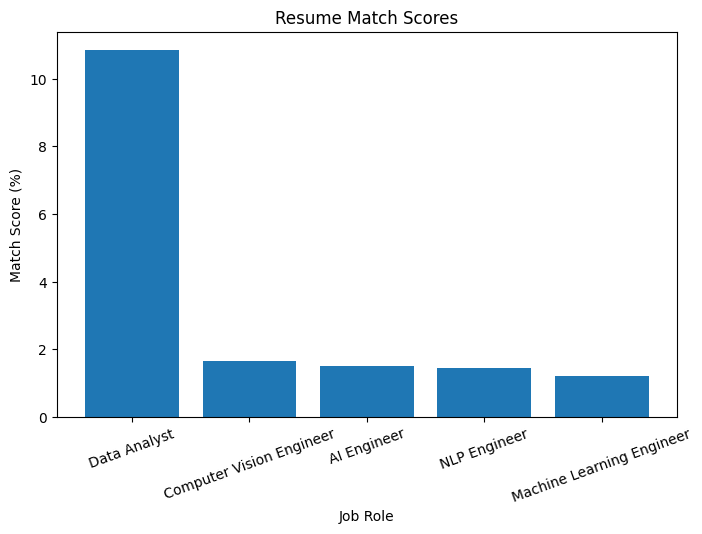

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(job_df["Role"], job_df["Match Score"])

plt.xlabel("Job Role")
plt.ylabel("Match Score (%)")
plt.title("Resume Match Scores")

plt.xticks(rotation=20)

plt.show()

In [ ]:
job_skill_dict = {
    "Data Analyst": [
        "python", "sql", "excel", "pandas", "power bi"
    ],

    "Machine Learning Engineer": [
        "python", "machine learning", "scikit-learn",
        "fastapi", "docker"
    ],

    "AI Engineer": [
        "python", "deep learning", "tensorflow",
        "keras", "apis"
    ],

    "NLP Engineer": [
        "python", "nlp", "transformers",
        "hugging face"
    ],

    "Computer Vision Engineer": [
        "python", "opencv", "cnn", "yolo"
    ]
}

In [ ]:
best_role = job_df.iloc[0]["Role"]

print("Recommended Role:", best_role)

Recommended Role: Data Analyst


In [ ]:
required_skills = job_skill_dict[best_role]

resume_skills = [skill.lower() for skill in skills_found]

missing_skills = []

for skill in required_skills:
    if skill not in resume_skills:
        missing_skills.append(skill)

print("Missing Skills:")
print(missing_skills)

Missing Skills:
['excel', 'power bi']


In [ ]:
found_skills = []

for skill in required_skills:
    if skill in resume_skills:
        found_skills.append(skill)

print("Skills Found")
print(found_skills)

Skills Found
['python', 'sql', 'pandas']


In [ ]:
def generate_roadmap(missing_skills):

    roadmap = []

    for i, skill in enumerate(missing_skills):

        roadmap.append(
            f"Week {i+1}: Learn {skill.title()}"
        )

    return roadmap

In [ ]:
roadmap = generate_roadmap(missing_skills)

for item in roadmap:
    print(item)

Week 1: Learn Excel
Week 2: Learn Power Bi


In [ ]:
print("="*50)

print("AI RESUME ANALYSIS REPORT")

print("="*50)

print()

print("Recommended Role:")
print(best_role)

print()

print("Match Score:")
print(job_df.iloc[0]["Match Score"], "%")

print()

print("Skills Found:")
print(found_skills)

print()

print("Missing Skills:")
print(missing_skills)

print()

print("Learning Roadmap:")

for step in roadmap:
    print(step)

print()

print("="*50)

AI RESUME ANALYSIS REPORT

Recommended Role:
Data Analyst

Match Score:
10.84 %

Skills Found:
['python', 'sql', 'pandas']

Missing Skills:
['excel', 'power bi']

Learning Roadmap:
Week 1: Learn Excel
Week 2: Learn Power Bi

